In [16]:
'''
new_vaccinations:
O gün uygulanan yeni toplam doz sayısıdır.

new_vaccinations_smoothed:
Günlük yeni dozların 7 günlük hareketli ortalamasıdır.

people_vaccinated_per_hundred:
Her 100 kişiden en az bir doz aşı olan kişi sayısıdır.

people_fully_vaccinated_per_hundred:
Her 100 kişiden tam aşılı kişi sayısıdır.

total_boosters_per_hundred:
Her 100 kişi başına uygulanan toplam hatırlatma dozu sayısıdır.

KULLANIM KURALLARI

total_vaccinations ve total_boosters doz sayısını gösterir.
Bir kişinin birden fazla dozu bulunabileceği için bu sütunlar kişi sayısı olarak yorumlanmaz.

Ülkeler arası karşılaştırmalarda people_vaccinated_per_hundred
ve people_fully_vaccinated_per_hundred kullanılacaktır.

Aşılama sütunları kümülatif olduğunda tarihler boyunca toplanmayacaktır.
Seçilen tarihteki veya haftanın son gözlemindeki hazır değer kullanılacaktır.
'''

'\nnew_vaccinations:\nO gün uygulanan yeni toplam doz sayısıdır.\n\nnew_vaccinations_smoothed:\nGünlük yeni dozların 7 günlük hareketli ortalamasıdır.\n\npeople_vaccinated_per_hundred:\nHer 100 kişiden en az bir doz aşı olan kişi sayısıdır.\n\npeople_fully_vaccinated_per_hundred:\nHer 100 kişiden tam aşılı kişi sayısıdır.\n\ntotal_boosters_per_hundred:\nHer 100 kişi başına uygulanan toplam hatırlatma dozu sayısıdır.\n\nKULLANIM KURALLARI\n\ntotal_vaccinations ve total_boosters doz sayısını gösterir.\nBir kişinin birden fazla dozu bulunabileceği için bu sütunlar kişi sayısı olarak yorumlanmaz.\n\nÜlkeler arası karşılaştırmalarda people_vaccinated_per_hundred\nve people_fully_vaccinated_per_hundred kullanılacaktır.\n\nAşılama sütunları kümülatif olduğunda tarihler boyunca toplanmayacaktır.\nSeçilen tarihteki veya haftanın son gözlemindeki hazır değer kullanılacaktır.\n'

In [17]:
# Ortak yardımcı fonksiyonlarla temiz ülke verisini yüklüyor ve temel kalite kontrolünü yapıyoruz.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import (
    load_countries,
    print_country_data_overview
)

df_countries = load_countries()
print_country_data_overview(df_countries)


Satır-sütun sayısı: (331169, 67)
Ülke sayısı: 198
İlk tarih: 2020-01-01 00:00:00
Son tarih: 2024-08-14 00:00:00
Tekrarlayan ülke-tarih kaydı: 0


In [18]:
#veri setindeki değerlerden kaç tane veri girişi yapılmış sayıyoruz
vaccination_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    toplam_doz_kaydi=('total_vaccinations', 'count'),
    ilk_doz_kaydi=('people_vaccinated', 'count'),
    tam_asi_kaydi=('people_fully_vaccinated', 'count'),
    hatirlatma_dozu_kaydi=('total_boosters', 'count'),
    ilk_doz_orani_kaydi=(
        'people_vaccinated_per_hundred',
        'count'
    ),
    tam_asi_orani_kaydi=(
        'people_fully_vaccinated_per_hundred',
        'count'
    )
)

vaccination_coverage['bos_tam_asi_orani_kaydi'] = (
    vaccination_coverage['toplam_satir']
    - vaccination_coverage['tam_asi_orani_kaydi']
)

print(
    vaccination_coverage
    .sort_values('tam_asi_orani_kaydi')
    .head(15)
)

                        toplam_satir  toplam_doz_kaydi  ilk_doz_kaydi  \
location                                                                
Eritrea                         1674                 0              0   
Liechtenstein                   1674               420            420   
Micronesia (country)            1674                 0              0   
Marshall Islands                1674                 0              0   
Vatican                         1674                 0              0   
Switzerland                     1674               893            893   
Palau                           1674                 0              0   
North Korea                     1674                 0              0   
Turkmenistan                    1674                 5              4   
Tuvalu                          1674                12             12   
Nauru                           1674                18             18   
Ethiopia                        1674               

In [19]:
#people_fully_vaccinated_per_hundred kaydı olan ülkelerde,
#boşlukların başta mı, arada mı, sonda mı olduğunu inceliyoruz
partial_full_vaccination_missing = vaccination_coverage[
    (vaccination_coverage['tam_asi_orani_kaydi'] > 0)
    & (vaccination_coverage['bos_tam_asi_orani_kaydi'] > 0)
].copy()

missing_full_vaccination_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_full_vaccination_missing.index
    )
    & df_countries[
        'people_fully_vaccinated_per_hundred'
    ].isna(),
    [
        'location',
        'date',
        'people_fully_vaccinated_per_hundred'
    ]
].copy()

valid_full_vaccination_range = (
    df_countries.loc[
        df_countries[
            'people_fully_vaccinated_per_hundred'
        ].notna()
    ]
    .groupby('location')
    .agg(
        ilk_dolu_tam_asi_tarihi=('date', 'min'),
        son_dolu_tam_asi_tarihi=('date', 'max')
    )
)

missing_full_vaccination_positions = (
    missing_full_vaccination_rows
    .join(
        valid_full_vaccination_range,
        on='location'
    )
)

missing_full_vaccination_positions['bosluk_konumu'] = 'arada'

missing_full_vaccination_positions.loc[
    missing_full_vaccination_positions['date']
    < missing_full_vaccination_positions[
        'ilk_dolu_tam_asi_tarihi'
    ],
    'bosluk_konumu'
] = 'başta'

missing_full_vaccination_positions.loc[
    missing_full_vaccination_positions['date']
    > missing_full_vaccination_positions[
        'son_dolu_tam_asi_tarihi'
    ],
    'bosluk_konumu'
] = 'sonda'

full_vaccination_missing_position_summary = (
    missing_full_vaccination_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['başta', 'arada', 'sonda'], fill_value=0)
)

print(full_vaccination_missing_position_summary)

bosluk_konumu  başta  arada  sonda
location                          
Afghanistan      492    825    217
Albania          394    732    329
Algeria          593    358    700
Andorra          428    878    315
Angola           493    867    217
...              ...    ...    ...
Venezuela        523    508    625
Vietnam          481    519    401
Yemen            554    842    238
Zambia           502    502    440
Zimbabwe         442     75    665

[190 rows x 3 columns]


In [20]:
print(
    "Kısmen eksik tam aşılama oranı bulunan ülke sayısı:",
    len(full_vaccination_missing_position_summary)
)

print(
    "Arada eksik tam aşılama oranı bulunan ülke sayısı:",
    (
        full_vaccination_missing_position_summary['arada']
        .gt(0)
        .sum()
    )
)

print(
    "Toplam arada eksik kayıt sayısı:",
    full_vaccination_missing_position_summary['arada'].sum()
)

Kısmen eksik tam aşılama oranı bulunan ülke sayısı: 190
Arada eksik tam aşılama oranı bulunan ülke sayısı: 183
Toplam arada eksik kayıt sayısı: 89972


In [21]:
#anormal veriler var mı kontrol ediyoruz
vaccination_value_checks = pd.Series({
    'Negatif toplam doz kaydı': ( #0 dan küçük mü
        df_countries['total_vaccinations']
        .lt(0)
        .sum()
    ),
    'Negatif ilk doz kişi kaydı': (
        df_countries['people_vaccinated']
        .lt(0)
        .sum()
    ),
    'Negatif tam aşılı kişi kaydı': (
        df_countries['people_fully_vaccinated']
        .lt(0)
        .sum()
    ),
    'Negatif hatırlatma dozu kaydı': (
        df_countries['total_boosters']
        .lt(0)#sıfırdan küçük mü bakılır
        .sum()
    ),
    'Tam aşılı kişi sayısının ilk doz kişi sayısını geçtiği kayıt': (
        (
            df_countries['people_fully_vaccinated']
            > df_countries['people_vaccinated']
        )
        .sum()
    )
})

print(vaccination_value_checks)

Negatif toplam doz kaydı                                        0
Negatif ilk doz kişi kaydı                                      0
Negatif tam aşılı kişi kaydı                                    0
Negatif hatırlatma dozu kaydı                                   0
Tam aşılı kişi sayısının ilk doz kişi sayısını geçtiği kayıt    0
dtype: int64


In [22]:
#kümülatif vaka toplamı 
cumulative_vaccination_columns = [
    'total_vaccinations',
    'people_vaccinated',
    'people_fully_vaccinated',
    'total_boosters'
]

vaccination_decrease_results = []

for column in cumulative_vaccination_columns:
    vaccination_changes = (
        df_countries[
            ['location', 'date', column]
        ]
        .sort_values(['location', 'date'])
        .copy()
    )

    vaccination_changes['degisim'] = (
        vaccination_changes
        .groupby('location')[column]
        .diff()
    )

    vaccination_decrease_results.append(
        {
            'gosterge': column,
            'azalan_kayit_sayisi': (
                vaccination_changes['degisim']
                .lt(0)
                .sum()
            )
        }
    )

vaccination_decrease_summary = (
    pd.DataFrame(vaccination_decrease_results)
    .sort_values('azalan_kayit_sayisi', ascending=False)
)

print(vaccination_decrease_summary.to_string(index=False))
#zaman içinde azalma görülmedi

               gosterge  azalan_kayit_sayisi
     total_vaccinations                    0
      people_vaccinated                    0
people_fully_vaccinated                    0
         total_boosters                    0


In [23]:
vaccination_daily = df_countries[
    [
        'location',
        'date',
        'people_vaccinated_per_hundred',
        'people_fully_vaccinated_per_hundred'
    ]
].copy()

vaccination_daily['hafta_baslangici'] = (
    vaccination_daily['date']
    - pd.to_timedelta(
        vaccination_daily['date'].dt.dayofweek,
        unit='D'
    )
)

weekly_vaccination_base = (
    vaccination_daily
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        hafta_sonu=('date', 'max')
    )
    .reset_index()
)

weekly_vaccination_observations = (
    vaccination_daily
    .dropna(
        subset=[
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    )
    .sort_values(['location', 'hafta_baslangici', 'date'])
    .groupby(
        ['location', 'hafta_baslangici'],
        as_index=False
    )
    .tail(1)
    .rename(
        columns={
            'date': 'gozlem_tarihi'
        }
    )
)

weekly_vaccinations = weekly_vaccination_base.merge(
    weekly_vaccination_observations[
        [
            'location',
            'hafta_baslangici',
            'gozlem_tarihi',
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    ],
    on=['location', 'hafta_baslangici'],
    how='left',
    validate='one_to_one'
)

weekly_vaccinations['gozlem_gecikmesi_gun'] = (
    weekly_vaccinations['hafta_sonu']
    - weekly_vaccinations['gozlem_tarihi']
).dt.days

weekly_vaccinations['veri_durumu'] = 'Aşı oranı verisi yok'

weekly_vaccinations.loc[
    weekly_vaccinations['gozlem_tarihi'].notna(),
    'veri_durumu'
] = 'Haftadaki son geçerli gözlem'

print(
    weekly_vaccinations[
        [
            'location',
            'hafta_baslangici',
            'hafta_sonu',
            'gozlem_tarihi',
            'gozlem_gecikmesi_gun',
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred',
            'veri_durumu'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici hafta_sonu gozlem_tarihi  gozlem_gecikmesi_gun  people_vaccinated_per_hundred  people_fully_vaccinated_per_hundred          veri_durumu
Afghanistan       2019-12-30 2020-01-05           NaT                   NaN                            NaN                                  NaN Aşı oranı verisi yok
Afghanistan       2020-01-06 2020-01-12           NaT                   NaN                            NaN                                  NaN Aşı oranı verisi yok
Afghanistan       2020-01-13 2020-01-19           NaT                   NaN                            NaN                                  NaN Aşı oranı verisi yok
Afghanistan       2020-01-20 2020-01-26           NaT                   NaN                            NaN                                  NaN Aşı oranı verisi yok
Afghanistan       2020-01-27 2020-02-02           NaT                   NaN                            NaN                                  NaN Aşı oranı verisi yok
Afghanista

In [24]:
weekly_vaccination_coverage = (
    weekly_vaccinations
    .groupby('location')
    .agg(
        toplam_hafta=('hafta_baslangici', 'size'),
        aşı_orani_bulunan_hafta=('gozlem_tarihi', 'count'),
        en_yuksek_gozlem_gecikmesi=(
            'gozlem_gecikmesi_gun',
            'max'
        )
    )
)

weekly_vaccination_coverage['asi_orani_olmayan_hafta'] = (
    weekly_vaccination_coverage['toplam_hafta']
    - weekly_vaccination_coverage['aşı_orani_bulunan_hafta']
)

print(
    weekly_vaccination_coverage
    .sort_values('aşı_orani_bulunan_hafta')
    .head(15)
)

                        toplam_hafta  aşı_orani_bulunan_hafta  \
location                                                        
Eritrea                          240                        0   
Liechtenstein                    240                        0   
Micronesia (country)             240                        0   
Marshall Islands                 240                        0   
Vatican                          240                        0   
Switzerland                      240                        0   
Palau                            240                        0   
North Korea                      240                        0   
Turkmenistan                     240                        4   
Tuvalu                           240                        9   
Nauru                            240                       12   
Ethiopia                         240                       13   
Luxembourg                       240                       13   
Venezuela                

In [25]:
weekly_vaccination_country_coverage = (
    weekly_vaccinations[
        weekly_vaccinations['gozlem_tarihi'].notna()
    ]
    .groupby('hafta_baslangici')['location']
    .nunique()
    .reset_index(name='ulke_sayisi')
    .sort_values(
        ['ulke_sayisi', 'hafta_baslangici'],
        ascending=[False, False]
    )
)

print(
    weekly_vaccination_country_coverage
    .head(15)
    .to_string(index=False)
)

hafta_baslangici  ulke_sayisi
      2021-09-06          157
      2021-09-20          154
      2021-10-25          150
      2021-08-30          150
      2021-08-16          150
      2021-09-27          149
      2021-11-08          148
      2021-10-18          148
      2021-10-11          148
      2021-10-04          148
      2021-11-15          147
      2021-11-01          147
      2021-09-13          147
      2021-08-23          146
      2021-07-19          146


In [26]:
selected_vaccination_week = (
    weekly_vaccination_country_coverage
    .iloc[0]['hafta_baslangici']
)

week_vaccination_comparison = (
    weekly_vaccinations.loc[
        weekly_vaccinations['hafta_baslangici']
        == selected_vaccination_week,
        [
            'location',
            'gozlem_tarihi',
            'gozlem_gecikmesi_gun',
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    ]
    .dropna(
        subset=[
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    )
    .copy()
)

print(
    "Seçilen hafta:",
    selected_vaccination_week.strftime('%d.%m.%Y')
)

print(
    "Karşılaştırılan ülke sayısı:",
    len(week_vaccination_comparison)
)

print(
    week_vaccination_comparison
    .sort_values(
        'people_fully_vaccinated_per_hundred',
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

Seçilen hafta: 06.09.2021
Karşılaştırılan ülke sayısı: 157
            location gozlem_tarihi  gozlem_gecikmesi_gun  people_vaccinated_per_hundred  people_fully_vaccinated_per_hundred
United Arab Emirates    2021-09-12                   0.0                          94.60                                82.87
               Qatar    2021-09-11                   1.0                          87.58                                82.31
               Malta    2021-09-12                   0.0                          78.20                                78.06
           Singapore    2021-09-12                   0.0                          82.37                                77.16
            Portugal    2021-09-10                   2.0                          87.25                                76.26
             Uruguay    2021-09-12                   0.0                          78.35                                74.74
             Bahrain    2021-09-12                   0.0          

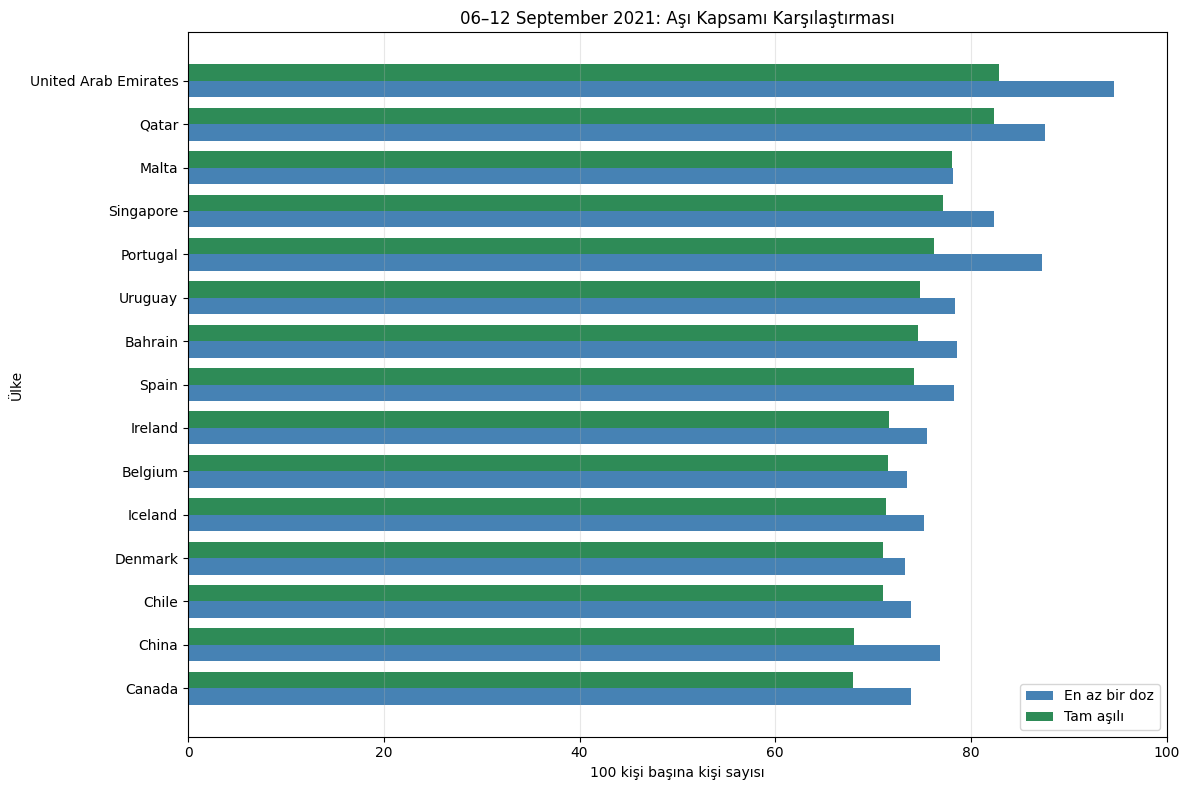

In [27]:
#ortak haftada aşı oranı grafiği
top_vaccination_coverage = (
    week_vaccination_comparison
    .nlargest(15, 'people_fully_vaccinated_per_hundred')
    .sort_values('people_fully_vaccinated_per_hundred')
)

y = np.arange(len(top_vaccination_coverage))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    y - bar_height / 2,
    top_vaccination_coverage[
        'people_vaccinated_per_hundred'
    ],
    height=bar_height,
    color='steelblue',
    label='En az bir doz'
)

ax.barh(
    y + bar_height / 2,
    top_vaccination_coverage[
        'people_fully_vaccinated_per_hundred'
    ],
    height=bar_height,
    color='seagreen',
    label='Tam aşılı'
)

ax.set_yticks(y)
ax.set_yticklabels(top_vaccination_coverage['location'])

ax.set_title(
    f'{selected_vaccination_week:%d}–'
    f'{(selected_vaccination_week + pd.Timedelta(days=6)):%d %B %Y}: '
    'Aşı Kapsamı Karşılaştırması'
)
ax.set_xlabel('100 kişi başına kişi sayısı')
ax.set_ylabel('Ülke')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

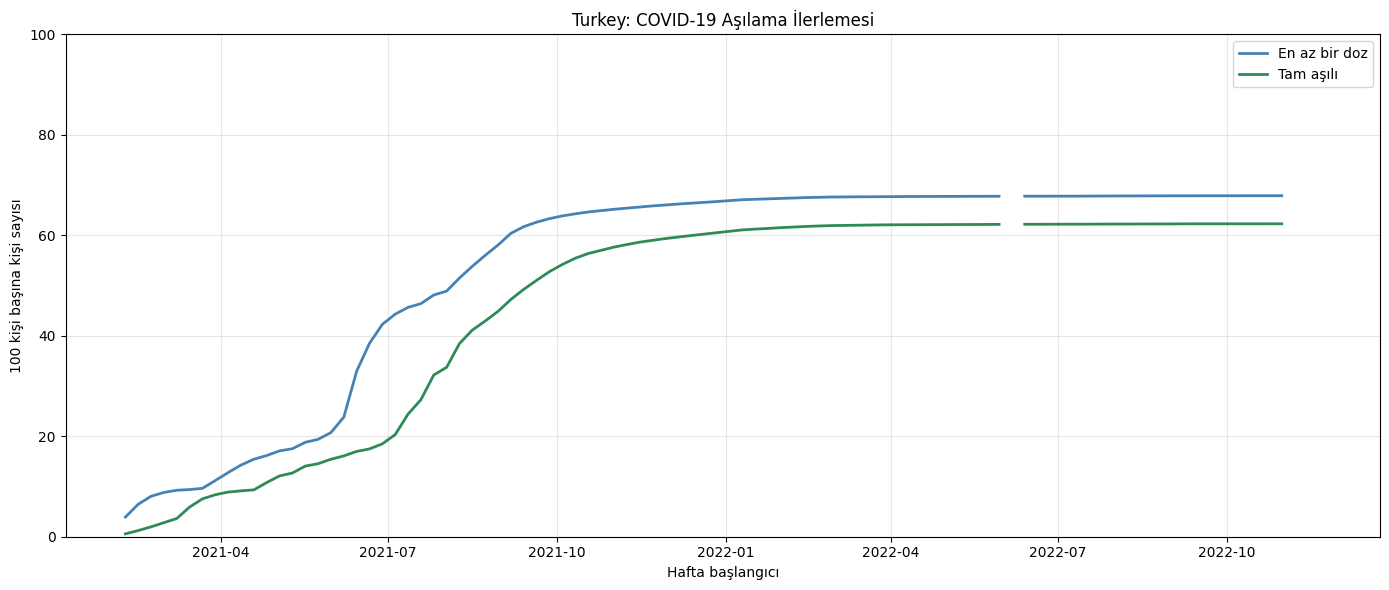

In [28]:
#Türkiye için en az bir doz ve tam aşılama oranı
selected_country = 'Turkey'

country_weekly_vaccinations = (
    weekly_vaccinations.loc[
        weekly_vaccinations['location'] == selected_country
    ]
    .sort_values('hafta_baslangici')
    .copy()
)

plt.figure(figsize=(14, 6))

plt.plot(
    country_weekly_vaccinations['hafta_baslangici'],
    country_weekly_vaccinations[
        'people_vaccinated_per_hundred'
    ],
    color='steelblue',
    linewidth=2,
    label='En az bir doz'
)

plt.plot(
    country_weekly_vaccinations['hafta_baslangici'],
    country_weekly_vaccinations[
        'people_fully_vaccinated_per_hundred'
    ],
    color='seagreen',
    linewidth=2,
    label='Tam aşılı'
)

plt.title(f'{selected_country}: COVID-19 Aşılama İlerlemesi')
plt.xlabel('Hafta başlangıcı')
plt.ylabel('100 kişi başına kişi sayısı')
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

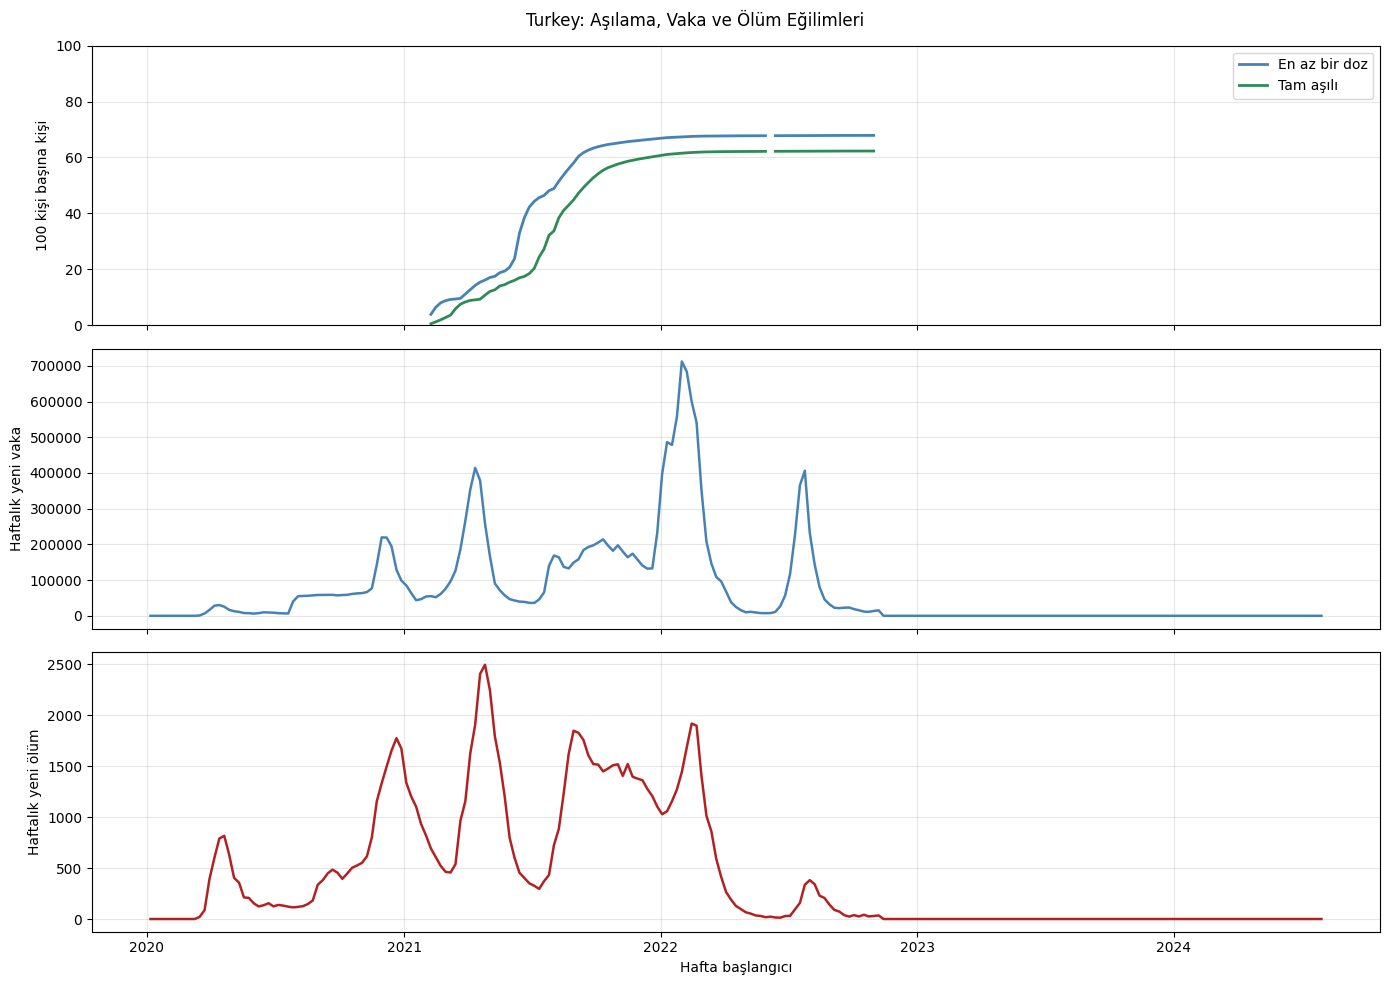

In [29]:
from pathlib import Path

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Proje kök klasörü bulunamadı.')

PROJECT_ROOT = find_project_root()

weekly_cases_data = pd.read_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'weekly_cases.csv',
    parse_dates=['hafta_baslangici']
)
weekly_deaths_data = pd.read_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'weekly_deaths.csv',
    parse_dates=['hafta_baslangici']
)

vaccination_case_death = (
    country_weekly_vaccinations[
        [
            'hafta_baslangici',
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    ]
    .merge(
        weekly_cases_data.loc[
            weekly_cases_data['location'] == selected_country,
            ['hafta_baslangici', 'haftalik_yeni_vaka']
        ],
        on='hafta_baslangici',
        how='left',
        validate='one_to_one'
    )
    .merge(
        weekly_deaths_data.loc[
            weekly_deaths_data['location'] == selected_country,
            ['hafta_baslangici', 'haftalik_yeni_olum']
        ],
        on='hafta_baslangici',
        how='left',
        validate='one_to_one'
    )
    .sort_values('hafta_baslangici')
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    vaccination_case_death['hafta_baslangici'],
    vaccination_case_death['people_vaccinated_per_hundred'],
    color='steelblue',
    linewidth=2,
    label='En az bir doz'
)
axes[0].plot(
    vaccination_case_death['hafta_baslangici'],
    vaccination_case_death['people_fully_vaccinated_per_hundred'],
    color='seagreen',
    linewidth=2,
    label='Tam aşılı'
)
axes[0].set_ylabel('100 kişi başına kişi')
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    vaccination_case_death['hafta_baslangici'],
    vaccination_case_death['haftalik_yeni_vaka'],
    color='steelblue',
    linewidth=1.8
)
axes[1].set_ylabel('Haftalık yeni vaka')
axes[1].grid(alpha=0.3)

axes[2].plot(
    vaccination_case_death['hafta_baslangici'],
    vaccination_case_death['haftalik_yeni_olum'],
    color='firebrick',
    linewidth=1.8
)
axes[2].set_ylabel('Haftalık yeni ölüm')
axes[2].set_xlabel('Hafta başlangıcı')
axes[2].grid(alpha=0.3)

fig.suptitle(f'{selected_country}: Aşılama, Vaka ve Ölüm Eğilimleri')
plt.tight_layout()
plt.show()


In [30]:
from pathlib import Path

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Proje kök klasörü bulunamadı.')

PROJECT_ROOT = find_project_root()

output_path = PROJECT_ROOT / 'data' / 'processed' / 'weekly_vaccinations.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)

weekly_vaccinations.to_csv(output_path, index=False, encoding='utf-8-sig')
print('Haftalık aşılama tablosu kaydedildi:', output_path.name)


Haftalık aşılama tablosu kaydedildi: weekly_vaccinations.csv
